# Cell Count Histogram

Loads `celltype_pert_number_of_cells.csv` generated by `04-perturbaion_distribution_Figure_1_GIK.rmd`, which is derived from the 6.3M post-QC cells with single `gene_target` perturbation, aggregates cell counts across each `perturbation`, and plots the distribution of total cells per perturbation.

This can also be done from the raw data filtering and then summing all perturbation single gene_targets (no | in target).

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [3]:
BASE_DIR = "/data/wholebrain_crispr_atlas/analysis"

CSV_PATH = Path(BASE_DIR, "visualization", "celltype_pert_number_of_cells.csv")

df = pd.read_csv(CSV_PATH)

required_columns = {"perturbation", "number of cells"}
missing_columns = required_columns.difference(df.columns)
if missing_columns:
    missing = ", ".join(sorted(missing_columns))
    raise KeyError(f"Missing required columns: {missing}")

cell_counts = pd.to_numeric(df["number of cells"], errors="coerce")
invalid_mask = cell_counts.isna() & df["number of cells"].notna()
if invalid_mask.any():
    invalid_examples = ", ".join(map(str, df.loc[invalid_mask, "number of cells"].head(5)))
    raise ValueError(f"Column 'number of cells' contains non-numeric values: {invalid_examples}")

if cell_counts.isna().any():
    raise ValueError("Column 'number of cells' contains missing values after numeric conversion")

df["number of cells"] = cell_counts

perturbation_totals = (
    df.groupby("perturbation", as_index=False)["number of cells"]
    .sum()
    .rename(columns={"number of cells": "total_cells"})
)

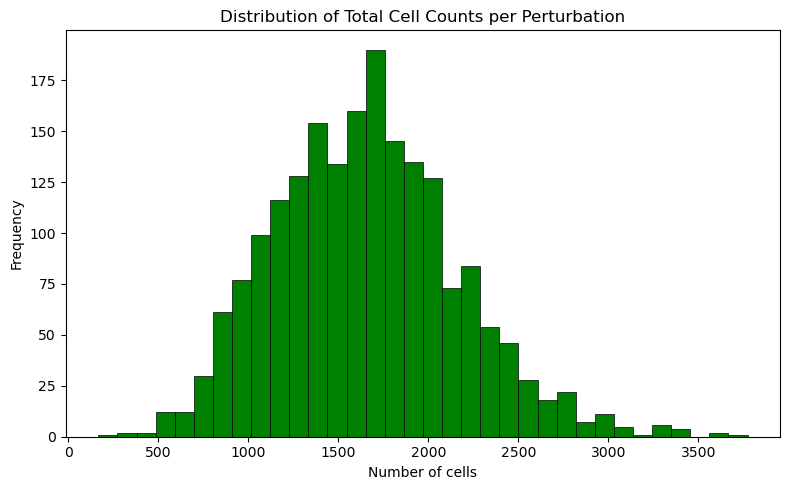

In [4]:
plt.figure(figsize=(8, 5))
plt.hist(
    perturbation_totals["total_cells"],
    bins=34,
    edgecolor="black",
    linewidth=0.5,
    color="green"  # light green
)
plt.title("Distribution of Total Cell Counts per Perturbation")
plt.xlabel("Number of cells")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()